In [1]:
%reset -f

import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

sys.path.append('/sdf/home/p/pierop/QuantyRIXS_ML')


from scripts import generate_dataset
from src.data import load_dataset
from src.sampling import latin_hypercube_sampling
from src.spectra import standardize_spectrum, interpolate_spectrum, align_spectrum, extract_from_experiment, extract_from_spec
from src.models.model import train_model, evaluate_model
from src.utils import load_config
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.signal import correlate, correlation_lags
from joblib import load

2026-08-13 15:34:21,945 [INFO] Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
2026-08-13 15:34:21,947 [INFO] Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2026-08-13 15:34:21,947 [INFO] NumExpr defaulting to 16 threads.


## **This cell generates a dataset with parameters:**
### Parameters
* <b>N</b>: number of simulations
* <b>d</b>: number of parameters being randomly assigned
* <b>output_path</b>: directory in which dataset.h5 will be created
* <b>lua_file_path</b>: path of lua file
* <b>l_bounds</b>: array of lower bounds for a parameter range in which each index represents a different parameter (ten_dq_i, ten_dq_f, etc.)
* <b>u_bounds</b>: array of upper bounds for a parameter range in which each index represents a different parameter (ten_dq_i, ten_dq_f, etc.)

In [2]:
L_BOUNDS = np.array([0.5, 0.75])
U_BOUNDS = np.array([5, 1])

config = load_config('co_terpy_L3L2_state1_CF_params.json')
PARAMS_SETUP = config['PARAMS_SETUP']
PARAMS_RIXS = config['PARAMS_RIXS']

output_path = '/Users/pierolujanpedreschi/SLAC-Project/Co/CoTerpy/6.30.2026_Test/TM_test1'
lua_file = 'TM_Ledge_spec_job.lua'
lua_file_path = '/Users/pierolujanpedreschi/SLAC-Project/QuantyRIXS_ML/'
# generate_dataset(N=1, d=2, output_path=output_path, lua_file_path=lua_file_path, l_bounds=L_BOUNDS, u_bounds=U_BOUNDS, PARAMS_SETUP=PARAMS_SETUP, PARAMS_RIXS=PARAMS_RIXS)

# Random data - only use for testing, not for training the model
# spectra, energies, params, metadata, index = load_dataset(Path(output_path) / 'dataset.h5')

# Assign reference_grid for later use
num_elements = int(round((PARAMS_RIXS['energy_end'] - PARAMS_RIXS['energy_start']) / PARAMS_RIXS['energy_step'])) + 1
reference_grid = np.linspace(PARAMS_RIXS['energy_start'], PARAMS_RIXS['energy_end'], num=num_elements)

## **This cell will train the model with the real dataset**

In [ ]:
# dataset_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/co_terpy_L3_data/dataset.h5'
dataset_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/co_terpy_L3L2_data/dataset.h5'

model, x_test, y_test = train_model(dataset_path, 'models/gradient_boost_co_terpy_L3L2.joblib')

2026-07-29 09:37:59,492 [INFO] Training Beginning


## **This cell will load the model which is already trained**

In [3]:
# model_path = '/sdf/home/p/pierop/QuantyRIXS_ML/models/gradient_boost_co_terpy_L3_state1_CF.joblib'
model_path = '/sdf/home/p/pierop/QuantyRIXS_ML/models/gradient_boost_co_terpy_L3L2_state1_CF.joblib'

model = load(model_path)

## **This cell will evaluate based on all the test data**

In [21]:
y_pred = model.predict(x_test)
violations = np.sum(y_pred[:, 1] > y_pred[:, 0])
print(f"Violations: {violations}/{len(y_pred)} ({violations/len(y_pred)*100:.1f}%)")

NameError: name 'x_test' is not defined

## **This cell will load data from an experimental spectrum**

Data shape: (351, 2)
First column shape before reshape: (351,)
Second column shape before reshape: (351,)
(351,)
(351,)
(351,)


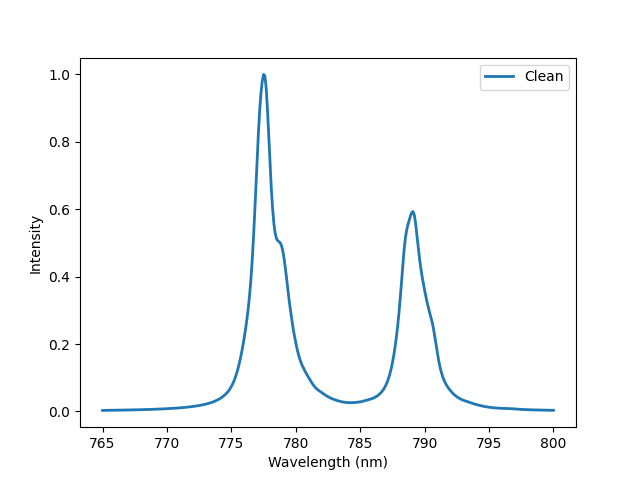

In [4]:
# Load data
# experimental_spectrum_path = '/Users/pierolujanpedreschi/SLAC-Project/QuantyRIXS_ML/data/experimental/Co_terpy_L3XAS_interp.txt'
# experimental_spectrum_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/experimental/Co_3+_L3.txt'
# experimental_spectrum_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/experimental/Co_3+_L3L2.txt'
# experimental_spectrum_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/experimental/Co_3+_L3L2_state2.txt'
# experimental_spectrum_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/experimental/Co_3+_L3_final.txt'
experimental_spectrum_path = '/sdf/home/p/pierop/QuantyRIXS_ML/data/experimental/Co_3+_L3L2_final.txt'


data = np.loadtxt(experimental_spectrum_path)

print(f"Data shape: {data.shape}")  # (351, 2)

# Extract energies from FIRST COLUMN and intensities from SECOND COLUMN (all 351 rows, column index 1)
first_column = data[:, 0]
second_column = data[:, 1]

print(f"First column shape before reshape: {first_column.shape}")  # (351,)
print(f"Second column shape before reshape: {second_column.shape}")  # (351,)

print(first_column.shape)
print(second_column.shape)
print(reference_grid.shape)

plt.figure()
# plt.plot(reference_grid, second_column, label='unstandardized', lw=2)

# Normalizes the intensities to be maxed at 1 and interpolates spectra onto reference_grid
experimental_spectrum = standardize_spectrum(first_column, second_column, reference_grid)

# # Reshape to (1, 351)
# x = second_column.reshape(1, -1) 

# experimental_spectrum = x/ np.max(x) # Normalizes the intensities to be maxed at 1
# experimental_energy = first_column.reshape(1, -1)

# print(experimental_energy.shape)
# print(experimental_spectrum.shape)
# print(reference_grid.shape)


plt.plot(reference_grid, experimental_spectrum, label='Clean', lw=2)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.show()

# Assign to noise this in shape (1, 351) if you want to add noise
noise_this = experimental_spectrum.copy()

## **Optional: Add Noise**

(351,)
(351,)


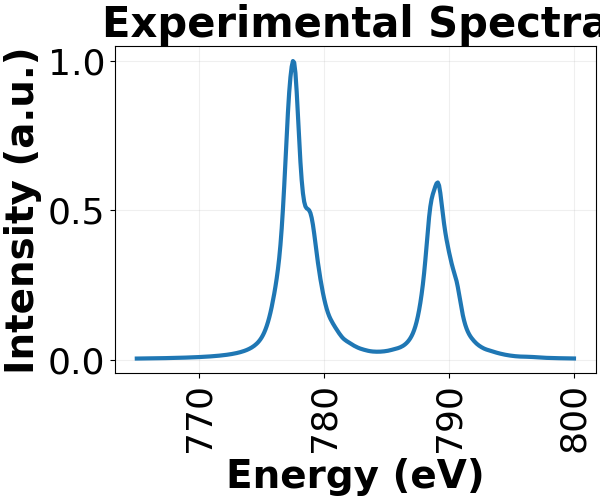

In [15]:
def add_noise(x, y, noise_level, noise_type='relative', seed=None):
    """
    Add Gaussian noise to a simulated spectrum.

    Parameters
    ----------
    x : array_like
        Spectrum x-axis (e.g., wavelength, wavenumber, energy).
    y : array_like
        Spectrum y-axis (intensity values).
    noise_level : float
        Magnitude of the noise.
        - If noise_type='relative': fraction of max(y) used as noise std
          (e.g., 0.01 = 1% noise).
        - If noise_type='absolute': noise standard deviation in y units.
        - If noise_type='snr': target signal-to-noise ratio.
    noise_type : str, optional
        'relative' (default), 'absolute', or 'snr'.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    y_noisy : ndarray
        Spectrum with added noise.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)

    if noise_type == 'relative':
        sigma = noise_level * np.max(np.abs(y))
    elif noise_type == 'absolute':
        sigma = noise_level
    elif noise_type == 'snr':
        signal_power = np.mean(y**2)
        sigma = np.sqrt(signal_power / noise_level)
    else:
        raise ValueError("noise_type must be 'relative', 'absolute', or 'snr'")

    noise = rng.normal(loc=0.0, scale=sigma, size=y.shape)
    return y + noise

experimental_spectrum = add_noise(reference_grid, noise_this.flatten(), noise_level=0.0, seed=42)
print(reference_grid.shape)
print(experimental_spectrum.shape)

# plt.figure(figsize=(10, 5))
# plt.title("Experimental Spectra", fontsize="32")
# plt.plot(reference_grid, experimental_spectrum, lw=2)
# plt.xlabel('Energy (eV)', fontsize="32")
# plt.ylabel('Intensity', fontsize="32")
# plt.xticks(rotation=90, fontsize=24)
# plt.yticks(fontsize=24)
# plt.show()

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

ax.plot(reference_grid, experimental_spectrum, linewidth=3)
ax.set_xlabel('Energy (eV)', fontweight='bold', fontsize=28)
ax.set_ylabel('Intensity (a.u.)', fontweight='bold', fontsize=28)
ax.set_title('Experimental Spectra', fontweight='bold', fontsize=30)
ax.tick_params(axis='both', labelsize=26)
ax.tick_params(axis='x', rotation=90)
ax.grid(alpha=0.2)

# plt.tight_layout()
plt.savefig('experimental_spectra.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## **This cell shifts an experimental spectrum for testing purposes**

In [17]:
from scipy.interpolate import interp1d

def interpolate_experiment(x, y, n_points, kind='cubic', x_range=None):
    """
    Interpolate a spectrum onto an evenly-spaced x-axis with n_points.

    Parameters
    ----------
    x : array_like
        Original spectrum x-axis (must be monotonic).
    y : array_like
        Original spectrum y-axis (intensity values).
    n_points : int
        Desired number of points in the output spectrum.
    kind : str, optional
        Interpolation type: 'linear', 'cubic', 'quadratic', 'nearest', etc.
        Default is 'cubic'.
    x_range : tuple (xmin, xmax), optional
        Range of the new x-axis. If None, uses (min(x), max(x)).

    Returns
    -------
    x_new : ndarray
        Evenly-spaced x-axis with shape (n_points,).
    y_new : ndarray
        Interpolated y-values with shape (n_points,).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Ensure x is sorted ascending (interp1d requires monotonic input)
    if np.any(np.diff(x) < 0):
        order = np.argsort(x)
        x, y = x[order], y[order]

    # Define new x-axis range
    if x_range is None:
        x_min, x_max = x[0], x[-1]
    else:
        x_min, x_max = x_range

    # Build the evenly-spaced x-axis
    x_new = np.linspace(x_min, x_max, n_points)

    # Interpolate
    interpolator = interp1d(x, y, kind=kind, bounds_error=False,
                            fill_value=(y[0], y[-1]))
    y_new = interpolator(x_new)

    return x_new, y_new

print(reference_grid.shape)
print(experimental_spectrum.shape)
print(experimental_spectrum.flatten().shape)



(351,)
(351,)
(351,)


## **Show how the experimental spectrum can be shifted**

(351,)
(351,)


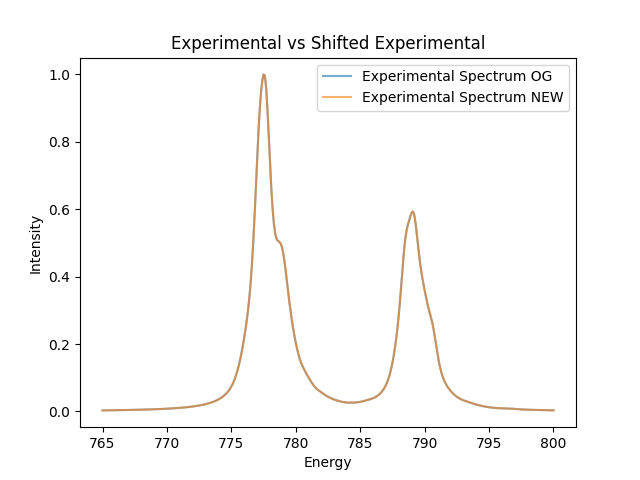

In [18]:
print(reference_grid.shape)
print(experimental_spectrum.shape)

plt.close('all')
plt.figure()
plt.plot(reference_grid, experimental_spectrum, label=f"Experimental Spectrum OG", alpha=0.6) # Original experiment spectrum

experimental_energy, experimental_spectrum = interpolate_experiment(reference_grid - 0, experimental_spectrum, num_elements, x_range=[PARAMS_RIXS['energy_start'],PARAMS_RIXS['energy_end']])

plt.plot(reference_grid, experimental_spectrum, label=f"Experimental Spectrum NEW", alpha=0.6) # Shifted experiment spectrum

plt.title("Experimental vs Shifted Experimental")
plt.xlabel("Energy")
plt.ylabel("Intensity")
plt.legend()
plt.show()


## **This cell simulates fit_experiment script**

In [19]:
mode = 'CF'
REPO_ROOT = Path('/sdf/home/p/pierop/QuantyRIXS_ML')

complex_spec_type = "co_terpy_L3L2_state1_CF"
config_file = f"{complex_spec_type}_params.json"
model_path = f"models/gradient_boost_{complex_spec_type}.joblib"
reference_path = REPO_ROOT / f"data/{complex_spec_type}_data/{complex_spec_type}_reference_spectrum.npy"
dataset_path = REPO_ROOT / 'data' / f'{complex_spec_type}_data' / 'dataset.h5'

# Load in all files
config = load_config(config_file)
model = load(model_path)
output_path = str(REPO_ROOT / 'data' / 'fit_output')
lua_file_path = str(REPO_ROOT)
lua_file = 'TM_Ledge_spec_job.lua'
reference_spectrum = np.load(reference_path)

PARAMS_SETUP = config['PARAMS_SETUP']
PARAMS_RIXS = config['PARAMS_RIXS']

num_elements = int(round((PARAMS_RIXS['energy_end'] - PARAMS_RIXS['energy_start']) / PARAMS_RIXS['energy_step'])) + 1
reference_grid = np.linspace(PARAMS_RIXS['energy_start'], PARAMS_RIXS['energy_end'], num=num_elements)
print(reference_grid.shape)

'''
# Align the desired spectrum to another and log the energy shift
aligned_experimental, energy_shift = align_spectrum(experiment_spectrum, reference_spectrum, reference_grid)
logger.info(f"Energy shift applied: {energy_shift:.4f} eV")

rmse, cosine_sim, pred_specs, pred_params = evaluate_model(model, aligned_experimental, None, reference_grid, args.output_path, PARAMS_SETUP, PARAMS_RIXS, args.lua_file, args.lua_file_path)


for now, non-aligned experimental spectra is showing better parameter predictions
'''

rmse, cosine_sim, pred_specs, pred_params = evaluate_model(model, experimental_spectrum.reshape(1, -1), None, reference_grid, output_path, PARAMS_SETUP, PARAMS_RIXS, lua_file, lua_file_path)

param_names_cf = ['ten_dq_i', 'ten_dq_f', 'Ds_3d_i', 'Dt_3d_i', 'scalef2', 'scalef4', 'scaleg']
param_names_ct = ['Delta_L1_i', 'Veg_L1_i', 'Vt2g_L1_i', 'Delta_L2_i', 'Vt2g_L2_i']
param_names = param_names_cf + (param_names_ct if mode == 'CT' else [])

print("Initial Predictions:")
print("=" * 40)
for i, name in enumerate(param_names):
    print(f"  {name:<15} = {pred_params[i]:.4f}")
print()

# Step 1: Access spectra and parameters from dataset
spectra, _, params, _, _ = load_dataset(dataset_path)
params = np.array([p.to_array() for p in params[:]])

int(spectra.shape[0] * 0.05)

exp = experimental_spectrum.flatten()
cos_sims = np.array([
    np.dot(exp, s) / (np.linalg.norm(exp) * np.linalg.norm(s)) 
    for s in spectra
])

# Step 2: Find training spectra with similar parameters to ML prediction
param_distances = np.linalg.norm(params - pred_params, axis=1)
candidate_indices = np.argsort(param_distances)[:int(spectra.shape[0] * 0.03)]

# Step 3: Among those candidates, find best spectral match by cosine similarity
candidate_cos_sims = cos_sims[candidate_indices]
best_candidates = candidate_indices[np.argsort(candidate_cos_sims)[::-1]]

print("Approximate Nearest Neighbors (top 5 by cosine similarity):")
print("=" * 60)
for rank, idx in enumerate(best_candidates[:10], start=1):
    print(f"\nRank {rank} — cos_sim={cos_sims[idx]:.4f}")
    for i, name in enumerate(param_names):
        print(f"  {name:<15} = {params[idx, i]:.4f}")

2026-08-13 15:44:11,367 [INFO] Evaluation Beginning


(351,)


/sdf/home/p/pierop/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/sdf/home/p/pierop/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/sdf/home/p/pierop/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/sdf/home/p/pierop/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/sdf/home/p/pierop/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  

Initial Predictions:
  ten_dq_i        = 2.7633
  ten_dq_f        = 2.1466
  Ds_3d_i         = 0.0588
  Dt_3d_i         = 0.0363
  scalef2         = 0.4547
  scalef4         = 0.6834
  scaleg          = 0.6274

Approximate Nearest Neighbors (top 5 by cosine similarity):

Rank 1 — cos_sim=0.9995
  ten_dq_i        = 3.0281
  ten_dq_f        = 2.3411
  Ds_3d_i         = 0.1487
  Dt_3d_i         = 0.0517
  scalef2         = 0.5697
  scalef4         = 0.7618
  scaleg          = 0.5608

Rank 2 — cos_sim=0.9991
  ten_dq_i        = 2.9820
  ten_dq_f        = 2.4243
  Ds_3d_i         = 0.0909
  Dt_3d_i         = 0.0636
  scalef2         = 0.4392
  scalef4         = 0.7049
  scaleg          = 0.6364

Rank 3 — cos_sim=0.9990
  ten_dq_i        = 2.8579
  ten_dq_f        = 2.5304
  Ds_3d_i         = 0.1079
  Dt_3d_i         = 0.0808
  scalef2         = 0.4806
  scalef4         = 0.7180
  scaleg          = 0.6132

Rank 4 — cos_sim=0.9990
  ten_dq_i        = 2.5805
  ten_dq_f        = 2.2403
  Ds_3d_

## **This cell plots the cross-correlation graph**

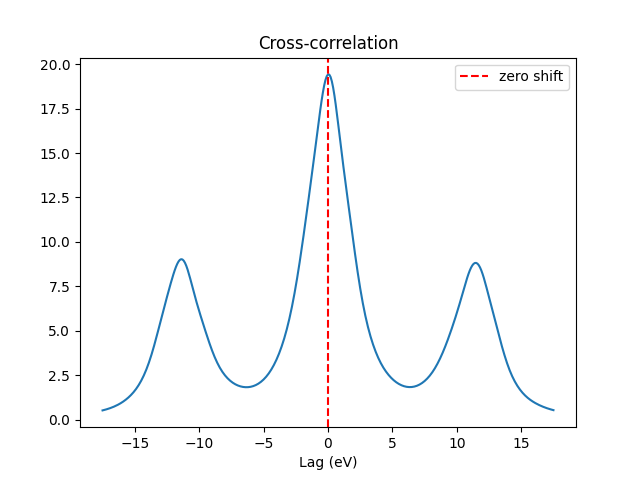

offset_index: 0
energy_shift: 0.0000 eV


In [20]:
# correlation = correlate(aligned_experimental.flatten(), pred_specs.flatten(), mode='same')
# lags = correlation_lags(len(aligned_experimental.flatten()), len(pred_specs.flatten()), mode='same')
correlation = correlate(experimental_spectrum.flatten(), pred_specs.flatten(), mode='same')
lags = correlation_lags(len(experimental_spectrum.flatten()), len(pred_specs.flatten()), mode='same')
x_spacing = reference_grid[1] - reference_grid[0]

plt.close('all')
plt.figure()
plt.plot(lags * x_spacing, correlation)
plt.xlabel('Lag (eV)')
plt.title('Cross-correlation')
plt.axvline(x=0, color='r', linestyle='--', label='zero shift')
plt.legend()
plt.show()

print(f"offset_index: {lags[np.argmax(correlation)]}")
print(f"energy_shift: {lags[np.argmax(correlation)] * x_spacing:.4f} eV")

## **This cell overlays the aligned experiment spectra and the predicted spectra**

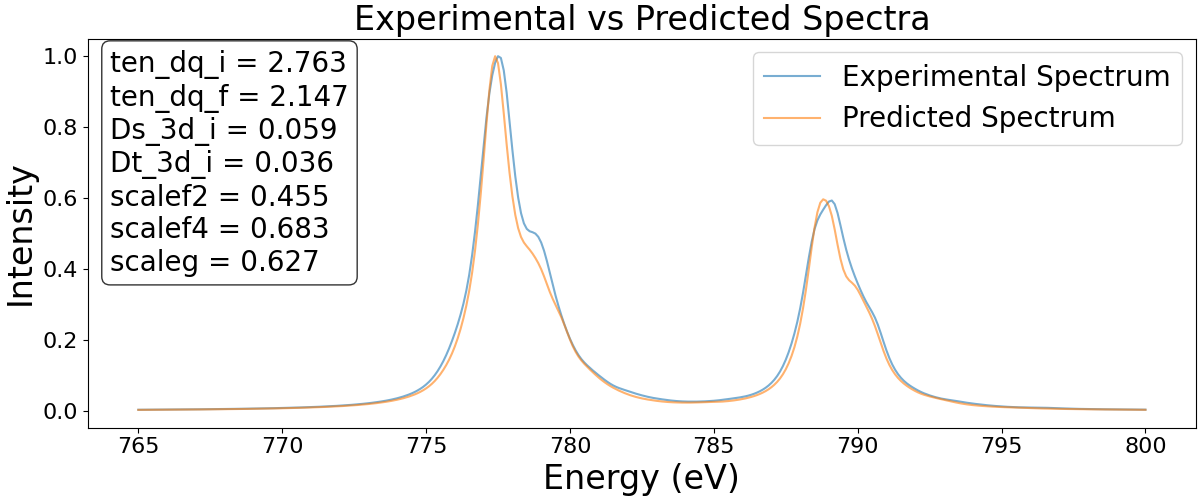

In [26]:
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

ax.plot(reference_grid, experimental_spectrum.flatten(), label="Experimental Spectrum", alpha=0.6)
ax.plot(reference_grid, pred_specs.flatten(), label="Predicted Spectrum", alpha=0.6)
ax.set_title("Experimental vs Predicted Spectra", fontsize="24")
ax.set_xlabel("Energy (eV)", fontsize="24")
ax.set_ylabel("Intensity", fontsize="24")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.legend(fontsize=20)

# Parameter text box
param_names = ['ten_dq_i', 'ten_dq_f', 'Ds_3d_i', 'Dt_3d_i', 'scalef2', 'scalef4', 'scaleg']
param_text = '\n'.join([f"{name} = {pred_params[i]:.3f}" for i, name in enumerate(param_names)])

ax.text(0.02, 0.97, param_text,
        transform=ax.transAxes,
        fontsize=20,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# plt.tight_layout()

# plt.show()

## **This Cell Plots the Experimental Spectrum and Rank 1 and 5 Nearest Neighbor Spectra**

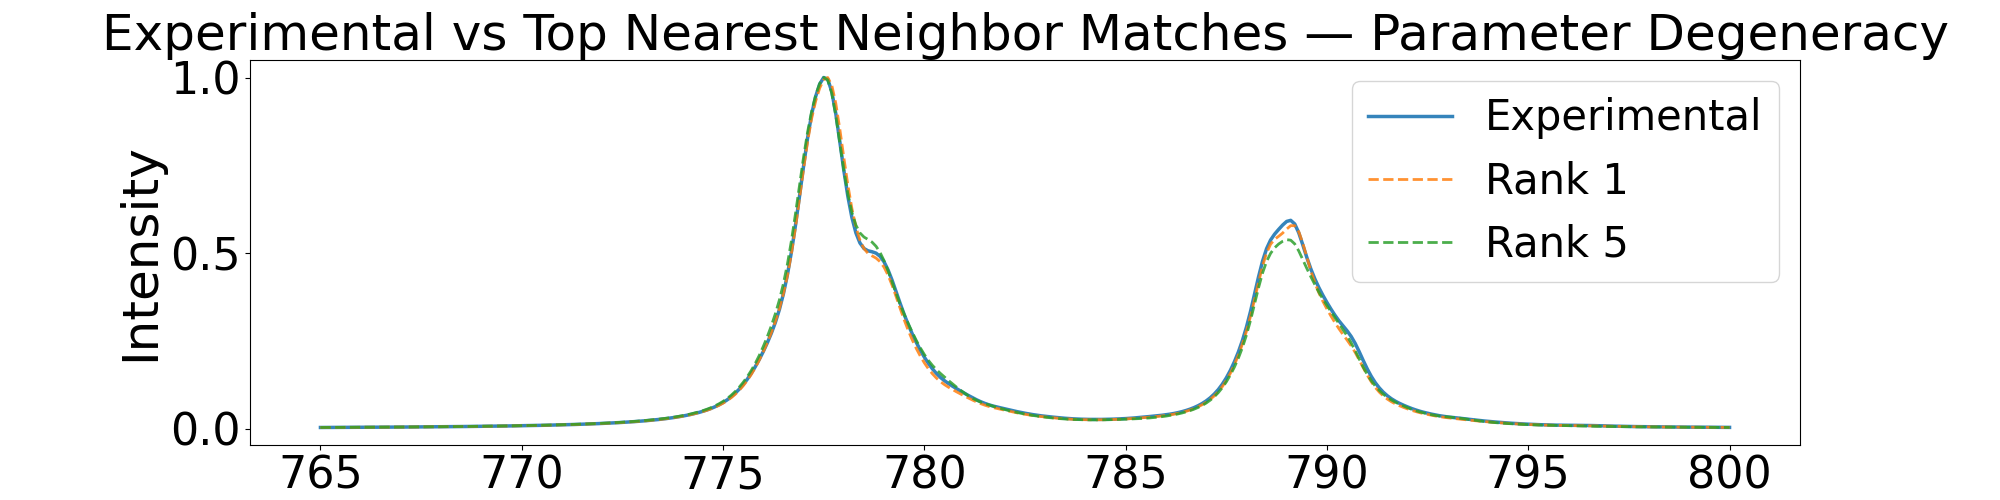

In [32]:
fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(reference_grid, exp, label='Experimental', color='C0', lw=2.5, alpha=0.9)
ax.plot(reference_grid, spectra[best_candidates[0]], 
        label=f'Rank 1', 
        color='C1', linestyle='--', lw=2, alpha=0.85)
ax.plot(reference_grid, spectra[best_candidates[4]], 
        label=f'Rank 5', 
        color='C2', linestyle='--', lw=2, alpha=0.85)

ax.set_xlabel('Energy (eV)', fontsize=36)
ax.set_ylabel('Intensity', fontsize=36)
ax.set_title('Experimental vs Top Nearest Neighbor Matches — Parameter Degeneracy', fontsize=36)
ax.tick_params(axis='both', labelsize=32)
ax.legend(fontsize=30)
# plt.tight_layout()
plt.savefig('experimental_vs_top5_spectra.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## **Other Graphs**

Output files: ['XASisoL3_GS_Oh_1.txt', 'XASisoL2_GS_Oh_1.txt']
Energy shift: 0.0000 eV


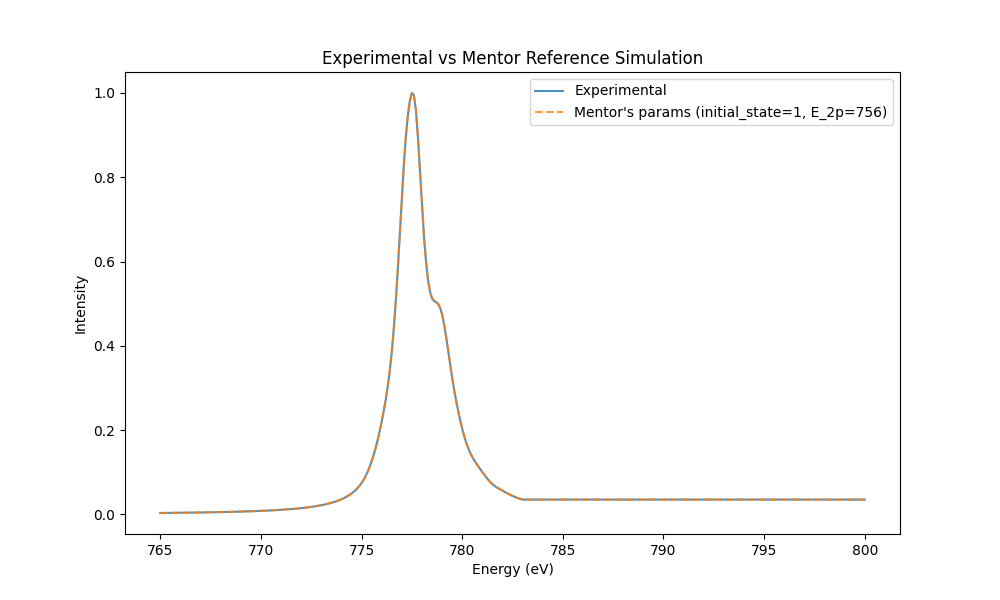

In [21]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.params import CrystalFieldParams
from src.spectra import build_quanty_dicts, generate_inp_quanty, generate_inp_rixs, run_quanty_sim, extract_from_spec, standardize_spectrum
from scipy.signal import correlate, correlation_lags

REPO_ROOT = Path('/sdf/home/p/pierop/QuantyRIXS_ML')
sim_dir = REPO_ROOT / 'data' / 'test_sim'
sim_dir.mkdir(parents=True, exist_ok=True)
lua_file_path = str(REPO_ROOT)



PARAMS_SETUP = {
    'atom': 'Co',
    'charge': '3+',
    'edge': 'L',
    'initial_state': 1,
    'rcn_file': str(REPO_ROOT / 'RCNparameter.txt')
}

PARAMS_I = {
    'NPsi_i': 50,
    'tenDq_3d_i': 3.2,
    'Ds_3d_i': 0.13,
    'Dt_3d_i': 0.06,
    'scalef2_3d3d_i': 0.58,
    'scalef4_3d3d_i': 0.8,
    'scale_3dSOC_i': 0.8,
    'U_3d_3d_i': 5,
}

PARAMS_F = {
    'NPsi_f': 50,
    'tenDq_3d_f': 2.4,
    'Ds_3d_f': 0.13,
    'Dt_3d_f': 0.06,
    'scalef2_3d3d_f': 0.58,
    'scalef4_3d3d_f': 0.8,
    'scale_3dSOC_f': 0.8,
    'U_3d_3d_f': 5,
    'U_2p_3d_f': 6,
    'scalef2_2p3d': 0.2,
    'scaleg': 0.6,
    'scale_2pSOC': 0.8,
    'E_2p': 756,
}

PARAMS_RIXS = {
    'energy_start': 765,
    'energy_end': 800,
    'energy_step': 0.1,
    'loss_start': -6,
    'loss_end': 15,
    'loss_step': 0.05,
    'FWHM_lorentz1': 1.0,
    'FWHM_lorentz1b': 0.2,
    'FWHM_lorentz2': 0.2,
    'Eshift': 0,
    'L3_L2_split': 783,
    'pol': 0,
}


# Mentor's reference parameters
# cf_params = CrystalFieldParams(
#     ten_dq_i=3.2, ten_dq_f=2.4,
#     Ds_3d_i=0.13, Dt_3d_i=0.06,
#     scalef2_3d3d_i=0.58, scalef4_3d3d_i=0.8,
#     scaleg=0.6,
#     E_2p=756.0
# )

num_elements = int(round((PARAMS_RIXS['energy_end'] - PARAMS_RIXS['energy_start']) / PARAMS_RIXS['energy_step'])) + 1
reference_grid = np.linspace(PARAMS_RIXS['energy_start'], PARAMS_RIXS['energy_end'], num=num_elements)

# params_i, params_f, params_setup, params_rixs = build_quanty_dicts(cf_params, PARAMS_SETUP, PARAMS_RIXS)
generate_inp_quanty(PARAMS_I, PARAMS_F, PARAMS_SETUP, sim_dir, 'GS_Oh.inp_quanty')
generate_inp_rixs(PARAMS_RIXS, sim_dir, 'GS_Oh.inp_rixs')

sim_result = run_quanty_sim(sim_dir, 'TM_Ledge_spec_job.lua', lua_file_path, timeout=120)

lines = sim_result.stdout.split('\n')
saved_files = list(set([line.split()[-1] for line in lines if line.endswith('.txt')]))
print(f"Output files: {saved_files}")

spec_file = saved_files[0]
extracted = extract_from_spec(sim_dir / spec_file)
simulated = standardize_spectrum(extracted['Energy'], extracted['Intensity'], reference_grid)

# Load experimental spectrum
from src.spectra import extract_from_experiment
exp_data = extract_from_experiment(REPO_ROOT / 'data' / 'experimental' / 'Co_3+_L3_final.txt')
experimental = standardize_spectrum(exp_data['Energy'], exp_data['Intensity'], reference_grid)

# Cross-correlation
correlation = correlate(experimental, simulated, mode='same')
lags = correlation_lags(len(experimental), len(simulated), mode='same')
x_spacing = reference_grid[1] - reference_grid[0]
offset_index = lags[np.argmax(correlation)]
energy_shift = -offset_index * x_spacing
print(f"Energy shift: {energy_shift:.4f} eV")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(reference_grid, experimental, label='Experimental', alpha=0.8)
plt.plot(reference_grid, simulated, label="Mentor's params (initial_state=1, E_2p=756)", alpha=0.8, linestyle='--')
plt.xlabel('Energy (eV)')
plt.ylabel('Intensity')
plt.title('Experimental vs Mentor Reference Simulation')
plt.legend()
plt.show()

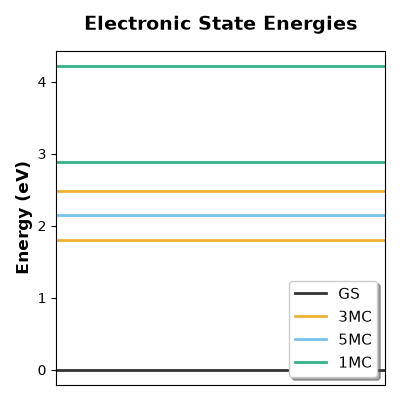

In [13]:
plt.close('all')
# Define positions and labels
lines = [
    (0, 'GS'),
    (1.8, '3MC'),
    (2.15, '5MC'),
    (2.48, '3MC'),
    (2.89, '1MC'),
    (4.22, '1MC')
]

# Define colors for each unique label using colorblind-friendly palette
color_map = {
    'GS': '#000000',    # Black
    '3MC': '#E69F00',   # Orange
    '5MC': '#56B4E9',   # Sky blue
    '1MC': '#009E73'    # Bluish green
}

plt.figure(figsize=(4, 4), dpi=100)

# Track which labels have been added to legend
added_labels = set()

# Plot horizontal lines
for position, label in lines:
    # Only add label if it's the first occurrence (for legend)
    if label not in added_labels:
        plt.axhline(y=position, color=color_map[label], linewidth=2, 
                   label=label, alpha=0.8)
        added_labels.add(label)
    else:
        plt.axhline(y=position, color=color_map[label], linewidth=2, alpha=0.8)

# Labels and styling
plt.ylabel('Energy (eV)', fontsize=12, fontweight='bold')
plt.title('Electronic State Energies', fontsize=14, fontweight='bold', pad=15)

# Legend - bottom right
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11, loc='lower right')

# Grid and styling
plt.xlim(0, 1)  # Adjust as needed
plt.tight_layout()
plt.xticks([])
plt.show()

---
## **Charge Transfer (CT) calculations — LMCT + MLCT**
Use `generate_inp_quanty_CT` and `TM_Ledge_CT_spec_job.lua` (in the `CT/` subdirectory).
The `.inp_rixs` file is identical in format to the non-CT version — use `generate_inp_rixs`.

In [ ]:
#### CT (Charge Transfer) ####

output_path = 'C:/Users/bpoult/Documents/Research/X-ray_Simulation_Software/Simulations/Co/CoTerpy/CT/'
fname_quanty = 'CT.inp_quanty'
fname_rixs = 'CT.inp_rixs'

# System identification — same as non-CT workflow.
params_setup = {
    'atom': 'Co',
    'charge': '3+',
    'edge': 'L',
    'initial_state': 1,
    'rcn_file': 'C:/Users/bpoult/Documents/Research/X-ray_Simulation_Software/QuantyRIXS_ML/RCNparameter.txt',
}

params_i = {
    # --- standard parameters (same keys as non-CT) ---
    'NPsi_i': 600,
    'tenDq_3d_i': 3.3,
    'Ds_3d_i': 0.18,
    'Dt_3d_i': 0.06,
    'scalef2_3d3d_i': 0.6,
    'scalef4_3d3d_i': 0.6,
    'scale_3dSOC_i': 1.0,
    'U_3d_3d_i': 5.0,
    # --- CT additions: LMCT (occupied ligand L1) ---
    'tenDq_L1_i': 0.4,
    'Delta_3d_L1_i': 0.7,
    'Veg_3d_L1_i': 3.6,
    'Vt2g_3d_L1_i': 0.9,
    # --- CT additions: MLCT (unoccupied ligand L2) ---
    'tenDq_L2_i': 0.0,
    'Delta_3d_L2_i': 3.2,
    'Veg_3d_L2_i': 0.0,
    'Vt2g_3d_L2_i': 1.2,
}

params_f = {
    # --- standard parameters (same keys as non-CT) ---
    'NPsi_f': 600,
    'tenDq_3d_f': 2.8,
    'Ds_3d_f': 0.165,
    'Dt_3d_f': 0.055,
    'scalef2_3d3d_f': 0.6,
    'scalef4_3d3d_f': 0.6,
    'scale_3dSOC_f': 1.0,
    'U_3d_3d_f': 5.0,
    'U_2p_3d_f': 6.0,
    'scalef2_2p3d': 0.6,
    'scaleg': 0.6,
    'scale_2pSOC': 1.0,
    'E_2p': 712.0,
    # --- CT additions: LMCT (occupied ligand L1) ---
    'tenDq_L1_f': 0.4,
    'Delta_3d_L1_f': -0.3,
    'Veg_3d_L1_f': 3.3,
    'Vt2g_3d_L1_f': 0.8,
    # --- CT additions: MLCT (unoccupied ligand L2) ---
    'tenDq_L2_f': 0.0,
    'Delta_3d_L2_f': 4.2,
    'Veg_3d_L2_f': 0.0,
    'Vt2g_3d_L2_f': 1.0,
}

params_rixs = {
    'energy_start': 705,
    'energy_end': 730,
    'energy_step': 0.1,
    'loss_start': -5,
    'loss_end': 20,
    'loss_step': 0.1,
    'FWHM_lorentz1': 0.35,
    'FWHM_lorentz1b': 0.7,
    'FWHM_lorentz2': 0.0,
    'Eshift': 0.0,
    'L3_L2_split': 717,
    'pol': 0,
}

generate_inp_quanty_CT(params_i, params_f, params_setup, output_path, fname_quanty)
generate_inp_rixs(params_rixs, output_path, fname_rixs)